# Data augmentation for the dataset

In [15]:
import pydicom
import cv2
import numpy as np
import albumentations as A
import os
import pandas as pd

csv_path = 'INbreast Release 1.0/INbreast.csv'
df = pd.read_csv(csv_path, delimiter=';')
df.columns = df.columns.str.strip()  # remove whitespace from column names
print(f"Total images in CSV: {len(df)}")

image_dir = 'INbreast Release 1.0/AllDICOMs'
output_dir = 'augmented_images'
os.makedirs(output_dir, exist_ok=True)

dicom_files = [f for f in os.listdir(image_dir) if f.endswith('.dcm')]

# build a mapping from file number to full DICOM filename
file_number_to_dicom = {}
for f in dicom_files:
    num = f.split('_')[0]
    file_number_to_dicom[num] = f

print(f"Number of unique DICOM file numbers: {len(file_number_to_dicom)}")

# augmentation pipeline (randomly flip, brightness/contrast, rotation, noise)
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Rotate(limit=15, p=0.5),
    A.GaussNoise(p=0.2)
])

augmented_rows = []
for idx, row in df.iterrows():
    file_number = str(row.get('File Name', '')).strip()
    label = str(row.get('Bi-Rads', '')).strip()
    dicom_filename = file_number_to_dicom[file_number]
    dicom_path = os.path.join(image_dir, dicom_filename)
    ds = pydicom.dcmread(dicom_path)
    img = ds.pixel_array.astype(np.float32)
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    orig_png_path = os.path.join(output_dir, f"{file_number}_orig.png")
    cv2.imwrite(orig_png_path, img)
    augmented_rows.append({'image_path': orig_png_path, 'label': label})
    for i in range(3):
        augmented = augment(image=img)['image']
        aug_png_path = os.path.join(output_dir, f"{file_number}_aug{i}.png")
        cv2.imwrite(aug_png_path, augmented)
        augmented_rows.append({'image_path': aug_png_path, 'label': label})

aug_df = pd.DataFrame(augmented_rows)
print(f"Total images after augmentation: {len(aug_df)}")

Total images in CSV: 410
Number of unique DICOM file numbers: 410
Total images after augmentation: 1640


In [16]:
from tqdm import tqdm

resize_dim = (224, 224)
valid_paths = aug_df['image_path'].apply(lambda x: isinstance(x, str) and os.path.isfile(x))
for img_path in tqdm(aug_df.loc[valid_paths, 'image_path'], desc='Resizing images'):
    img = cv2.imread(img_path)
    if img is not None:
        resized_img = cv2.resize(img, resize_dim, interpolation=cv2.INTER_AREA)
        cv2.imwrite(img_path, resized_img)
    else:
        print(f"Warning: Could not read {img_path}")
print("All images resized to 224x224.")

Resizing images: 100%|██████████| 1640/1640 [02:51<00:00,  9.54it/s]

All images resized to 224x224.


In [17]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    aug_df[['image_path', 'label']],
    test_size=0.2,
    random_state=42,
    stratify=aug_df['label']
)

train_df.to_csv('train_split.csv', index=False)
test_df.to_csv('test_split.csv', index=False)

print(f"Train set: {len(train_df)} samples")
print(f"Test set: {len(test_df)} samples")

Train set: 1312 samples
Test set: 328 samples


# Resize the images to 224x224 pixels

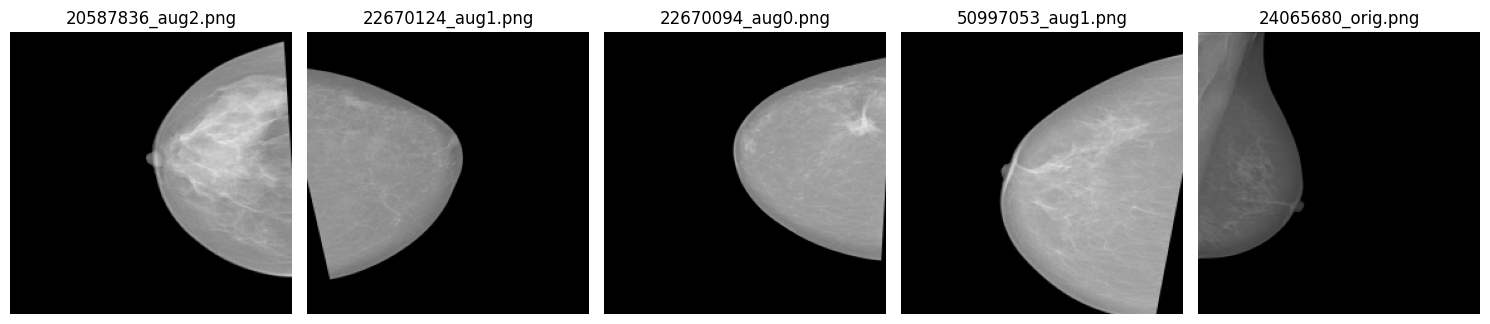

In [18]:
# see random sample of augmented images
import random
import matplotlib.pyplot as plt

sample_images = random.sample(list(aug_df['image_path']), 5)
plt.figure(figsize=(15, 5))
for i, img_path in enumerate(sample_images):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(os.path.basename(img_path))
    plt.axis('off')
plt.tight_layout()
plt.show()